In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings

In [2]:
warnings.filterwarnings('ignore')

In [3]:
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.style.use('seaborn-v0_8-darkgrid')

In [6]:
# Loading the dataset

data = pd.read_csv('../data/raw/HHS_Unaccompanied_Alien_Children_Program.csv')

df = data.copy()


df.head(10)

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0
5,"December 14, 2025",8.0,35.0,4.0,"2,462",8.0
6,"December 11, 2025",7.0,47.0,9.0,"2,437",10.0
7,"December 10, 2025",10.0,54.0,5.0,"2,439",9.0
8,"December 09, 2025",4.0,30.0,7.0,"2,443",8.0
9,"December 08, 2025",9.0,27.0,9.0,"2,440",4.0


In [5]:
# Column names clean-up

df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Date', 'Children apprehended and placed in CBP custody*', 'Children in CBP custody', 'Children transferred out of CBP custody', 'Children in HHS Care', 'Children discharged from HHS Care']


In [9]:
# Basic MetaData

print ("The number of rows: ", df.shape[0])
print ("\nThe number of columns: ", df.shape[1])
print ("\nThe name of the columns: \n\n", df.columns.to_list())
print ("The datatypes of the column: \n\n", df.dtypes)
print ("\nThe info: ")
df.info()

The number of rows:  1170

The number of columns:  6

The name of the columns: 

 ['Date', 'Children apprehended and placed in CBP custody*', 'Children in CBP custody', 'Children transferred out of CBP custody', 'Children in HHS Care', 'Children discharged from HHS Care']
The datatypes of the column: 

 Date                                                object
Children apprehended and placed in CBP custody*    float64
Children in CBP custody                            float64
Children transferred out of CBP custody            float64
Children in HHS Care                                object
Children discharged from HHS Care                  float64
dtype: object

The info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                            

In [11]:
print ("Number of duplicated rows: \n", df.duplicated().sum())
print ("\nNumber of null values: \n", df.isnull().sum())

Number of duplicated rows: 
 449

Number of null values: 
 Date                                               450
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64


In [22]:
df.describe()

,Date,Children apprehended and placed in CBP custody,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
count,720,720.000000,720.000000,720.000000,720.000000,720.000000
mean,2024-07-06 05:29:59.999999744,93.523611,171.494444,128.668056,6061.275000,173.406944
min,2023-01-12 00:00:00,0.000000,7.000000,0.000000,1972.000000,0.000000
25%,2023-10-16 18:00:00,12.000000,36.000000,14.000000,2467.750000,19.750000
50%,2024-07-05 12:00:00,99.000000,193.000000,157.000000,6406.500000,181.000000
75%,2025-03-25 06:00:00,147.250000,263.250000,199.250000,8010.250000,267.000000
max,2025-12-21 00:00:00,333.000000,531.000000,440.000000,11516.000000,505.000000
std,NaN,72.646625,126.354965,97.322012,2833.070109,125.702841


### Minimal cleaning for EDA

In [12]:
# removing null rows

df.dropna(how = "all", inplace= True)

In [15]:
# drop duplicated rows

df.drop_duplicates(inplace = True)

In [16]:
# Remove asterisk from column name

df.columns = df.columns.str.replace('*', '', regex=False).str.strip()

In [17]:
df.columns.to_list()

['Date',
 'Children apprehended and placed in CBP custody',
 'Children in CBP custody',
 'Children transferred out of CBP custody',
 'Children in HHS Care',
 'Children discharged from HHS Care']

In [18]:
# Fix hhs_care to numeric (remove commas if any)


df['Children in HHS Care'] = pd.to_numeric(
    df['Children in HHS Care'].astype(str).str.replace(',', '').str.strip(),
    errors='coerce'
)

In [19]:
# converting the date from "object" to "date"

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop = True)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 6 columns):
 #   Column                                          Non-Null Count  Dtype         
---  ------                                          --------------  -----         
 0   Date                                            720 non-null    datetime64[ns]
 1   Children apprehended and placed in CBP custody  720 non-null    float64       
 2   Children in CBP custody                         720 non-null    float64       
 3   Children transferred out of CBP custody         720 non-null    float64       
 4   Children in HHS Care                            720 non-null    int64         
 5   Children discharged from HHS Care               720 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 33.9 KB


In [21]:
print (f"The date range is: {df["Date"].min()} to {df["Date"].max()}")

The date range is: 2023-01-12 00:00:00 to 2025-12-21 00:00:00


In [40]:
# checking for Date continuity

full_range = pd.date_range(start=df['Date'].min(), end=df['Date'].max(), freq='D')
missing_dates = full_range.difference(df['Date'])

print(f"Total calendar days in range : {len(full_range)}")
print(f"Actual records in dataset    : {len(df)}")
print(f"Missing dates (no recording) : {len(missing_dates)}")

# Check day of week distribution
df['day_of_week'] = df['Date'].dt.day_name()
dow_counts = df['day_of_week'].value_counts()
print()
print("Records per day of week:")
print(dow_counts)

Total calendar days in range : 1075
Actual records in dataset    : 720
Missing dates (no recording) : 355

Records per day of week:
day_of_week
Tuesday      149
Thursday     147
Wednesday    147
Monday       145
Sunday       130
Friday         2
Name: count, dtype: int64


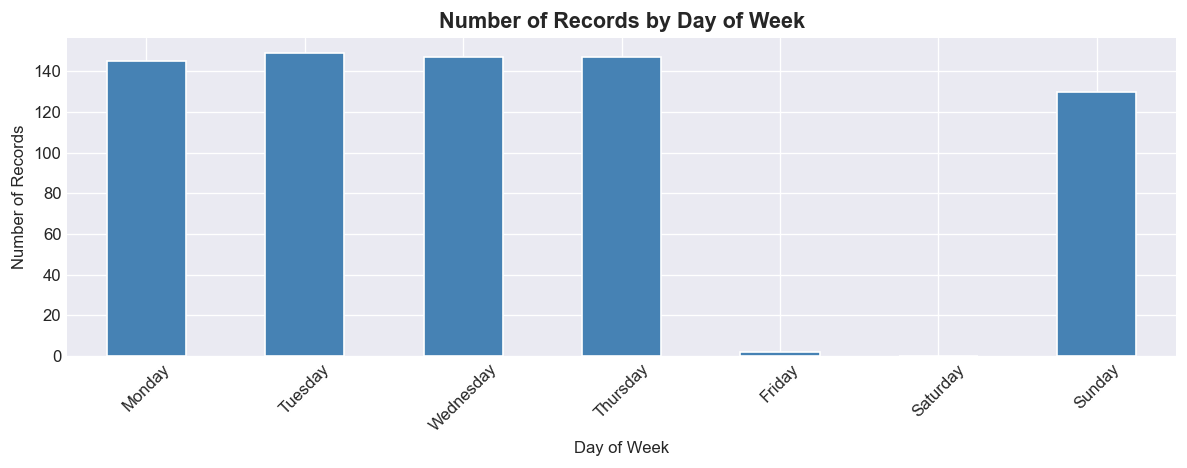

In [41]:
# Day of Week Distribution Plot

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_ordered = df['day_of_week'].value_counts().reindex(days_order, fill_value=0)

plt.figure(figsize=(10, 4))
dow_ordered.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Number of Records by Day of Week', fontsize=13, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/day_of_week_distribution.png', bbox_inches='tight')
plt.show()

df.drop(columns=['day_of_week'], inplace=True)

In [24]:
#Renaming columns

df.rename(columns={
    'Children apprehended and placed in CBP custody': 'cbp_apprehended',
    'Children in CBP custody': 'cbp_custody',
    'Children transferred out of CBP custody': 'cbp_transferred',
    'Children in HHS Care': 'hhs_care',
    'Children discharged from HHS Care': 'hhs_discharged'
}, inplace=True)

print(df.columns.tolist())

['Date', 'cbp_apprehended', 'cbp_custody', 'cbp_transferred', 'hhs_care', 'hhs_discharged']


## EDA

### All Variables over time

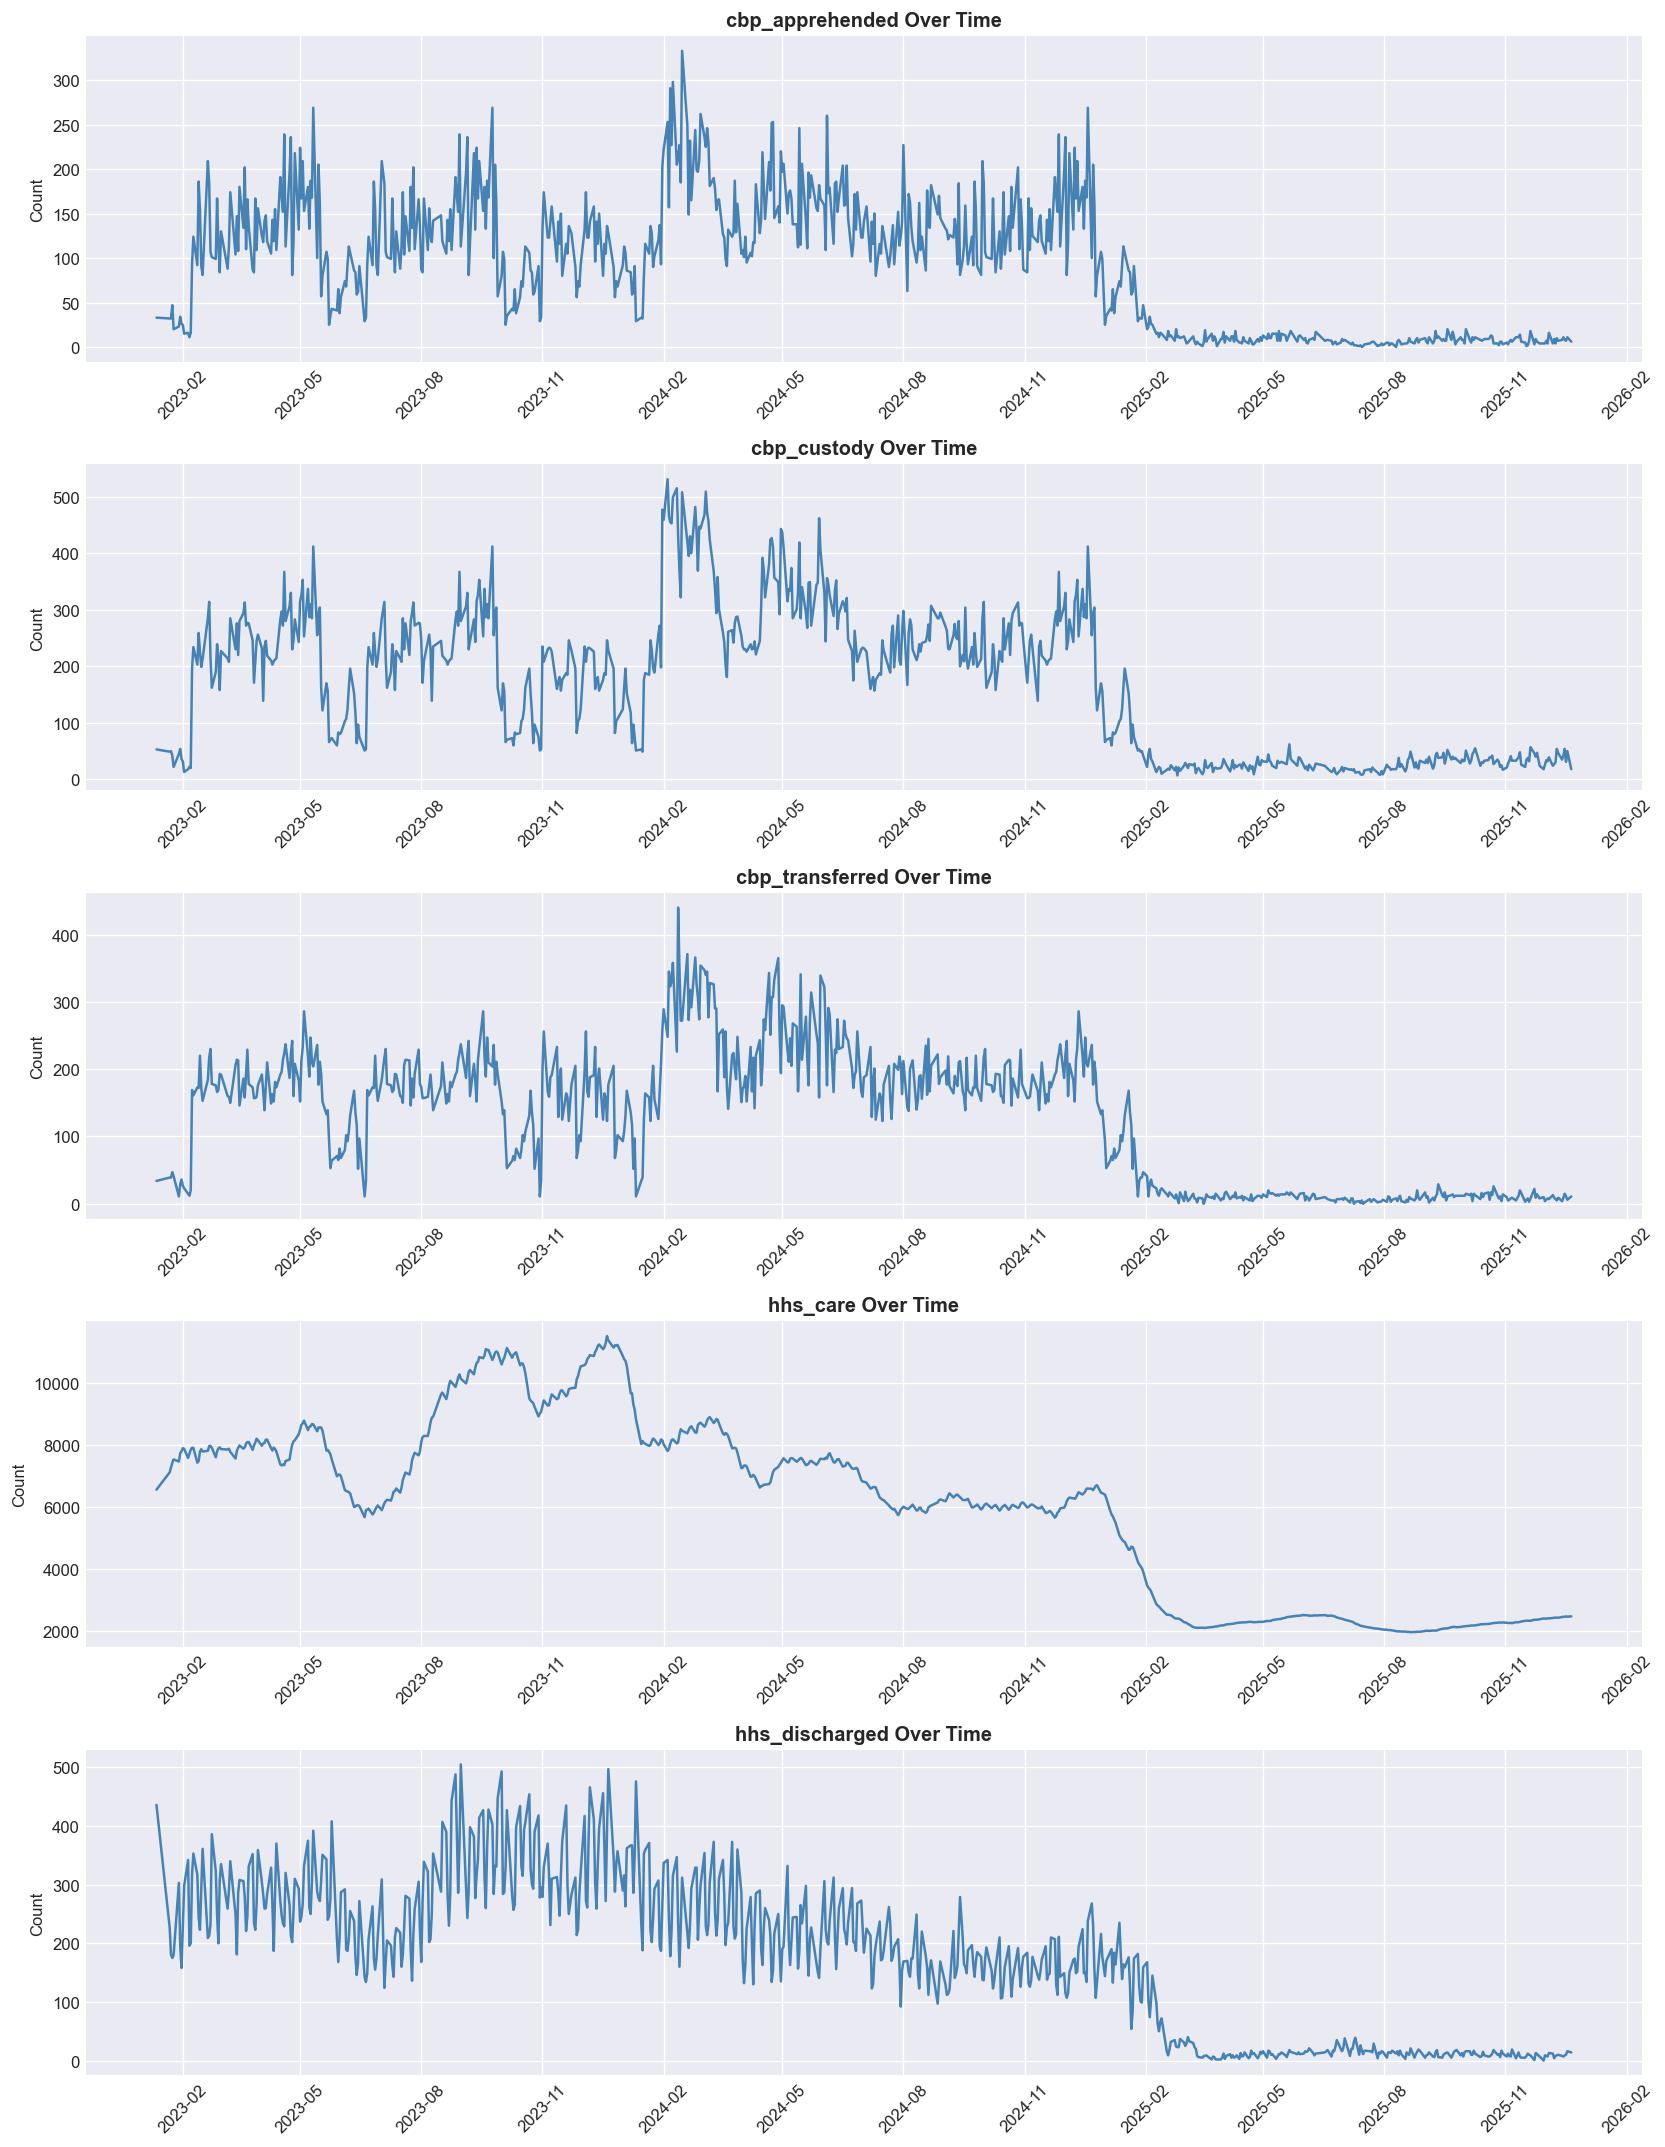

In [26]:
cols = ['cbp_apprehended', 'cbp_custody', 'cbp_transferred', 'hhs_care', 'hhs_discharged']

fig, axes = plt.subplots(len(cols), 1, figsize=(14, 18))

for i, col in enumerate(cols):
    axes[i].plot(df['Date'], df[col], linewidth=1.5, color='steelblue')
    axes[i].set_title(f'{col} Over Time', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    axes[i].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()

plt.savefig('../reports/figures/all_columns_trend.png', bbox_inches='tight')
plt.show()

### Target Variable in Detail

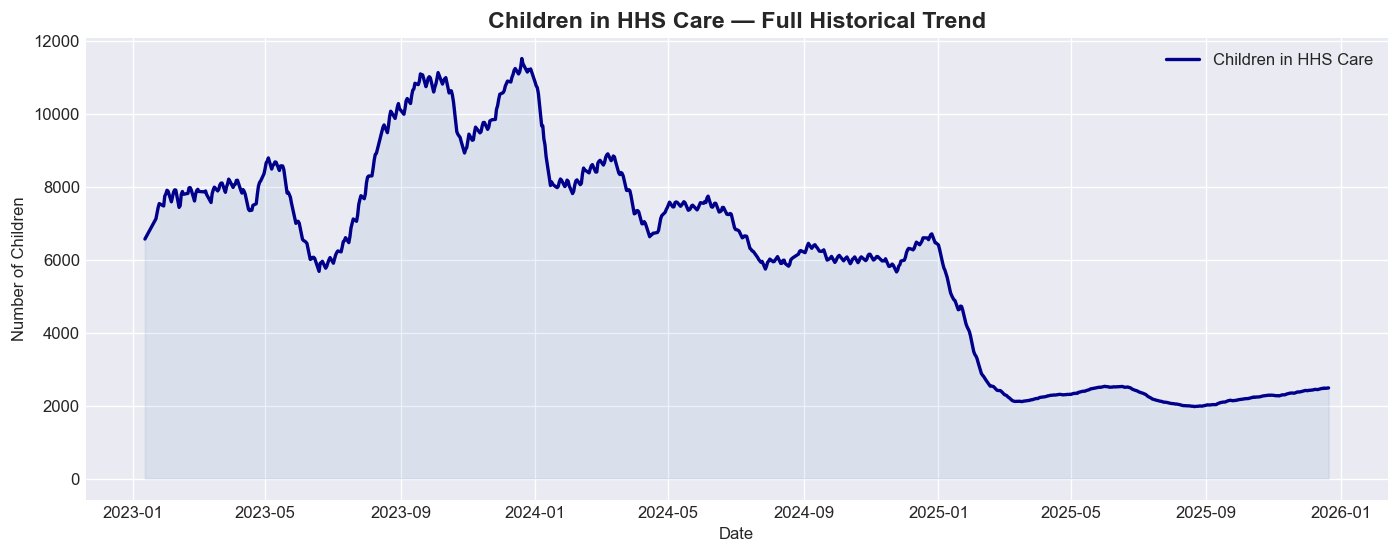

In [27]:
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['hhs_care'], color='darkblue', linewidth=2, label='Children in HHS Care')
plt.fill_between(df['Date'], df['hhs_care'], alpha=0.1, color='steelblue')
plt.title('Children in HHS Care — Full Historical Trend', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Children')
plt.legend()

plt.savefig('../reports/figures/hhs_care_trend.png', bbox_inches='tight')
plt.show()

### Intake vs Discharge

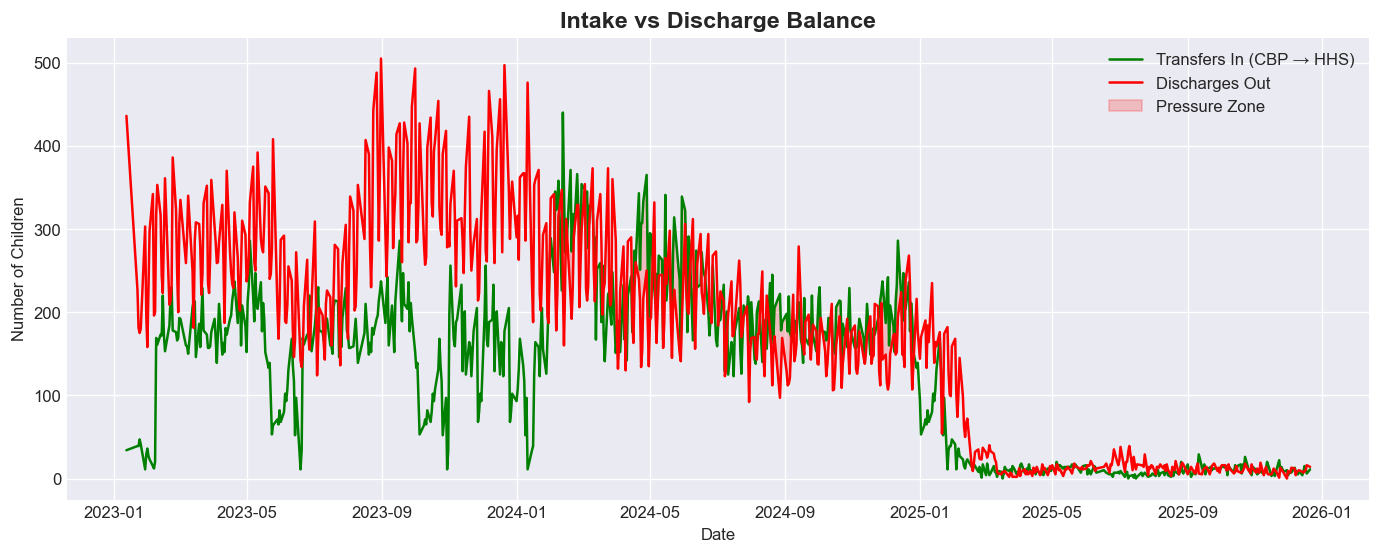

In [28]:
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['cbp_transferred'], color='green', linewidth=1.5, label='Transfers In (CBP → HHS)')
plt.plot(df['Date'], df['hhs_discharged'], color='red', linewidth=1.5, label='Discharges Out')

plt.fill_between(df['Date'], df['cbp_transferred'], df['hhs_discharged'],
                 where=(df['cbp_transferred'] > df['hhs_discharged']),
                 alpha=0.2, color='red', label='Pressure Zone')
plt.title('Intake vs Discharge Balance', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Children')
plt.legend()

plt.savefig('../reports/figures/intake_vs_discharge.png', bbox_inches='tight')
plt.show()

### Rolling Average of HHS Care Load

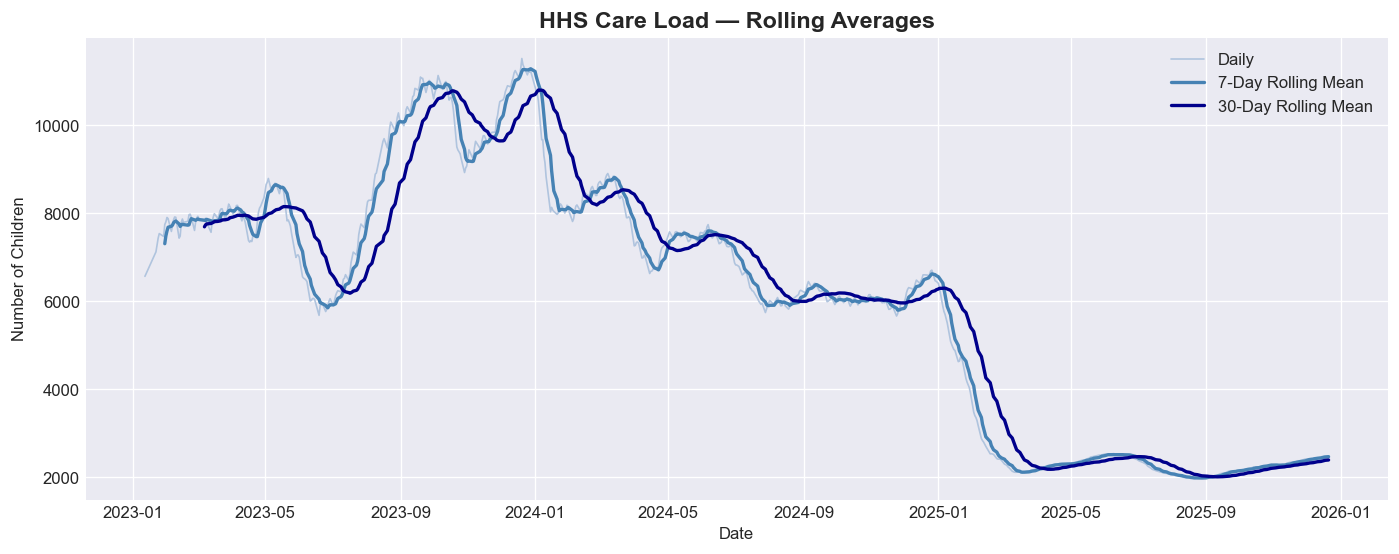

In [29]:
df['hhs_care_7d'] = df['hhs_care'].rolling(window=7).mean()
df['hhs_care_30d'] = df['hhs_care'].rolling(window=30).mean()

plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['hhs_care'], color='lightsteelblue', linewidth=1, label='Daily')
plt.plot(df['Date'], df['hhs_care_7d'], color='steelblue', linewidth=2, label='7-Day Rolling Mean')
plt.plot(df['Date'], df['hhs_care_30d'], color='darkblue', linewidth=2, label='30-Day Rolling Mean')
plt.title('HHS Care Load — Rolling Averages', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Children')
plt.legend()

plt.savefig('../reports/figures/rolling_averages.png', bbox_inches='tight')
plt.show()

### Correlation Heatmap

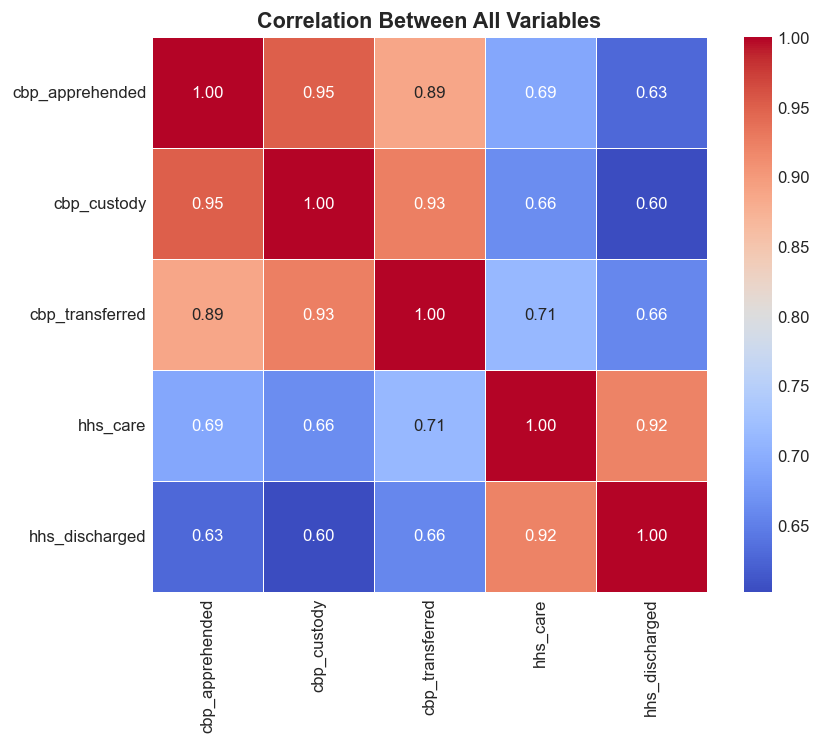

In [30]:
plt.figure(figsize=(8, 6))
corr = df[['cbp_apprehended', 'cbp_custody', 'cbp_transferred', 'hhs_care', 'hhs_discharged']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, square=True)
plt.title('Correlation Between All Variables', fontsize=13, fontweight='bold')

plt.savefig('../reports/figures/correlation_heatmap.png', bbox_inches='tight')
plt.show()

### Seasonal Decomposition

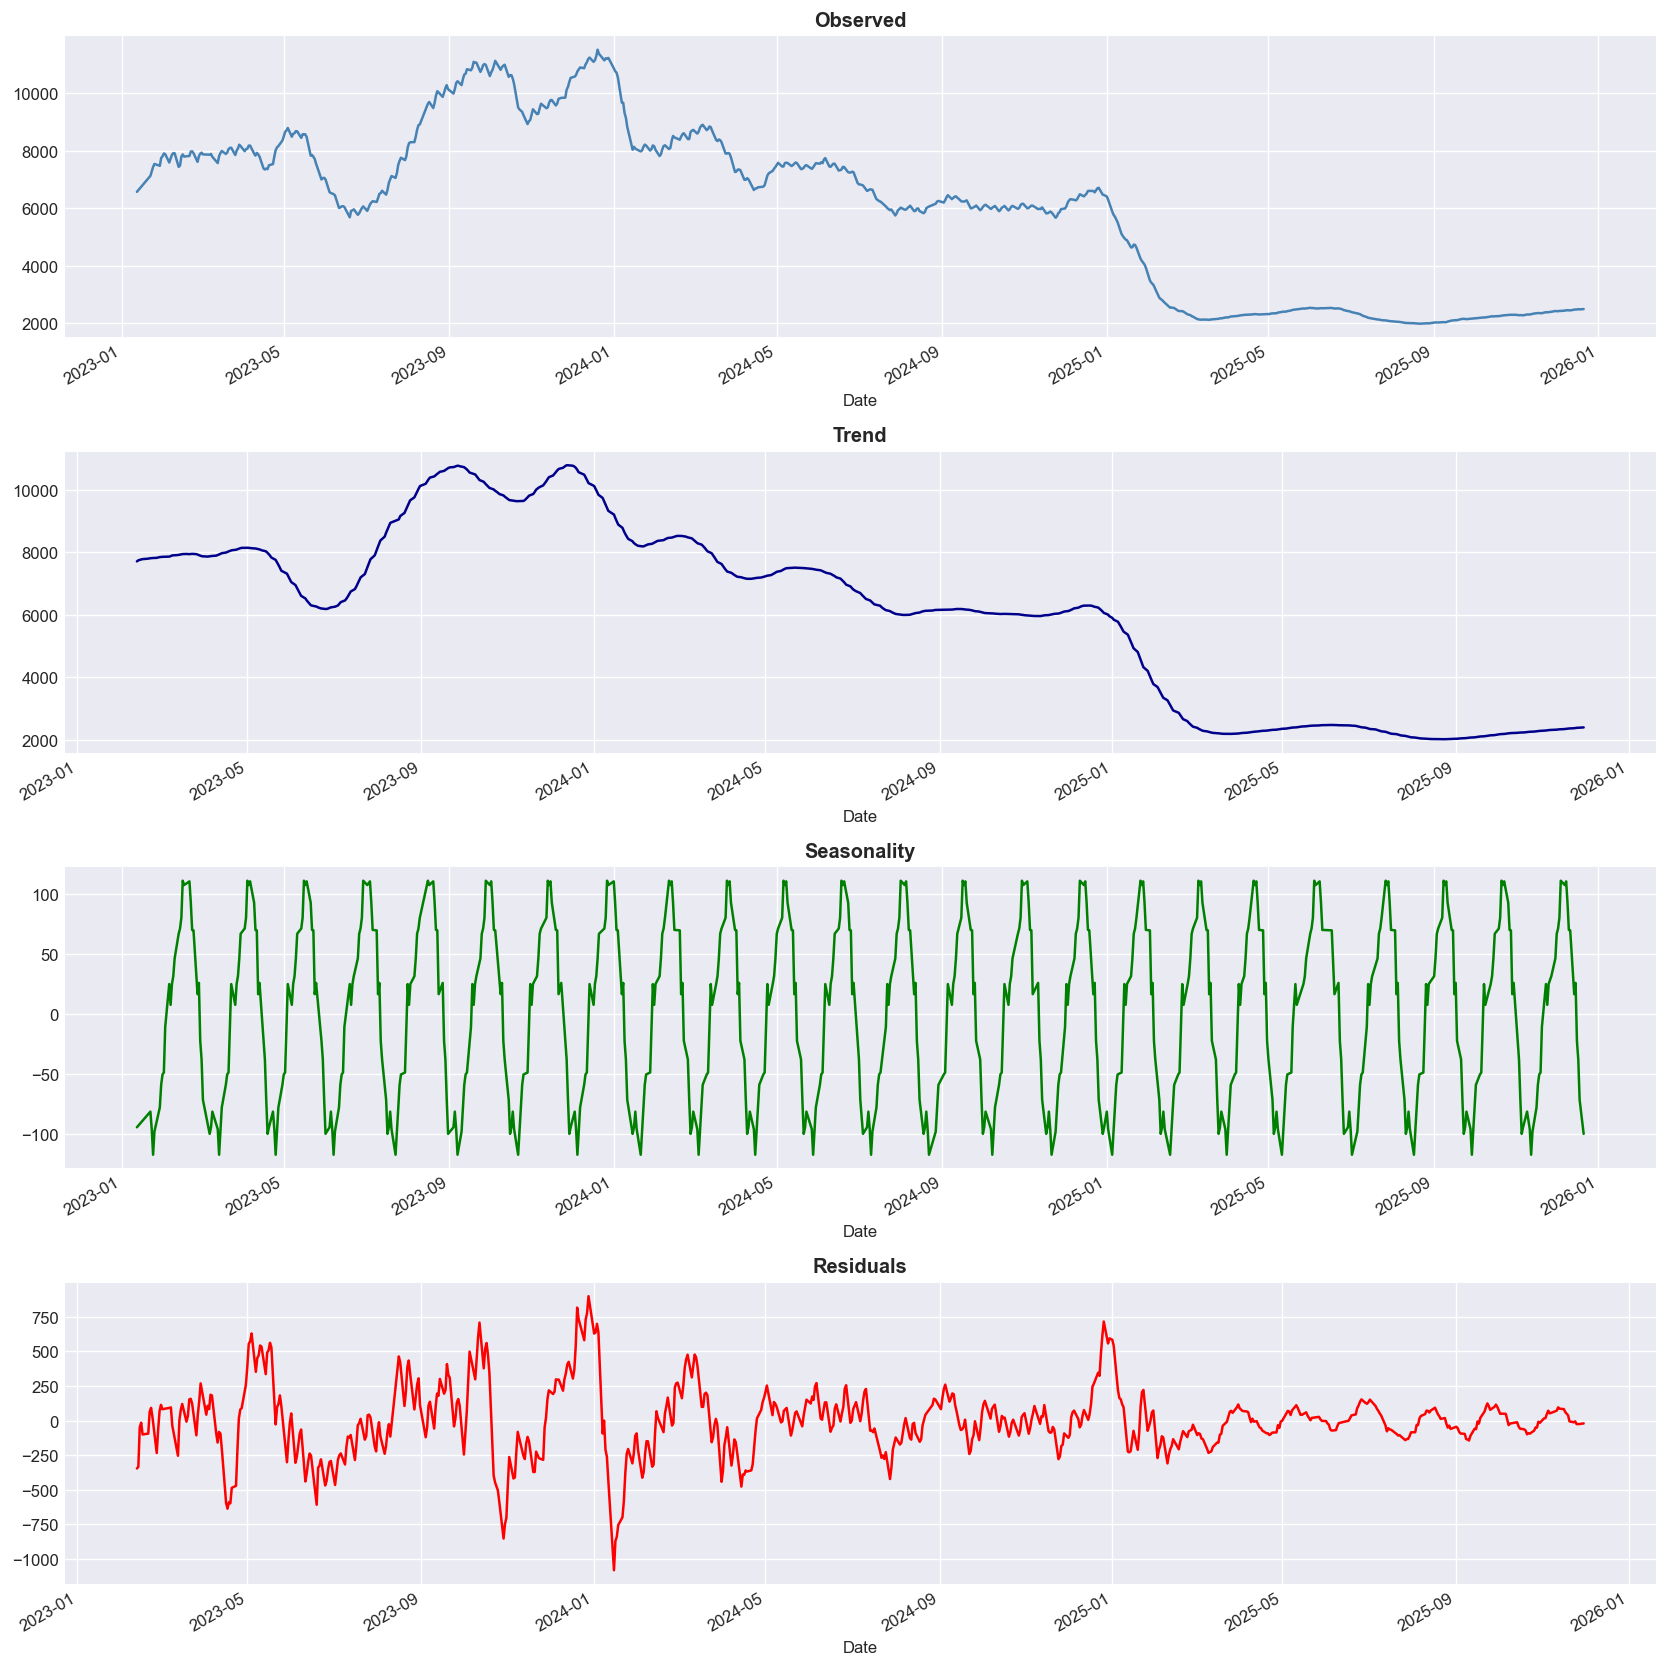

In [31]:
df_indexed = df.set_index('Date')['hhs_care'].dropna()

decomposition = seasonal_decompose(df_indexed, model='additive', period=30)

fig, axes = plt.subplots(4, 1, figsize=(14, 14))

decomposition.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Observed', fontweight='bold')

decomposition.trend.plot(ax=axes[1], color='darkblue')
axes[1].set_title('Trend', fontweight='bold')

decomposition.seasonal.plot(ax=axes[2], color='green')
axes[2].set_title('Seasonality', fontweight='bold')

decomposition.resid.plot(ax=axes[3], color='red')
axes[3].set_title('Residuals', fontweight='bold')

plt.tight_layout()

plt.savefig('../reports/figures/decomposition.png', bbox_inches='tight')
plt.show()

### Monthly Average HHS Care Load

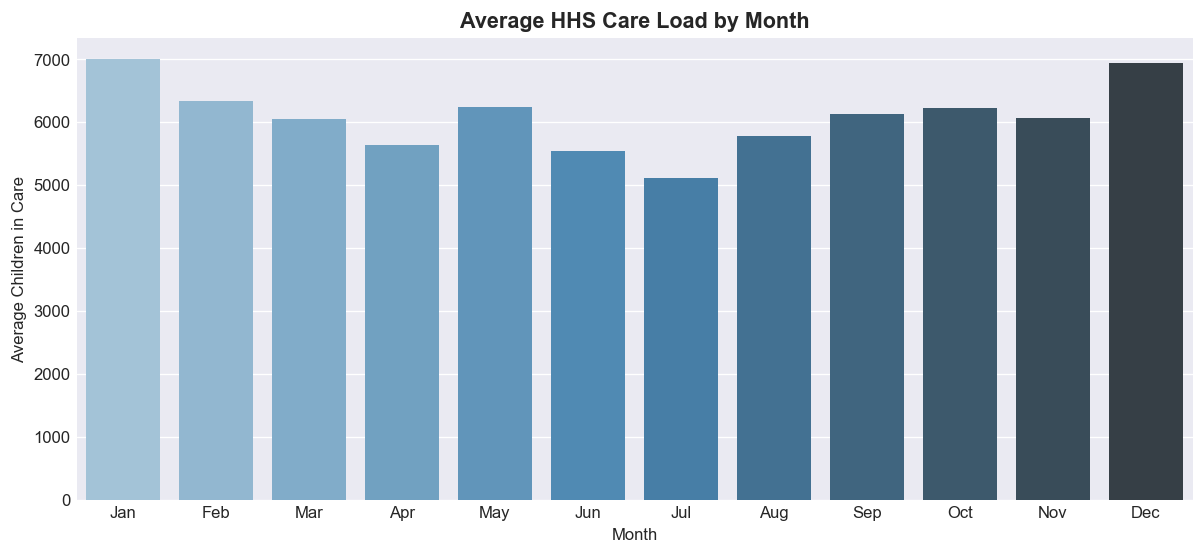

In [32]:
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year

monthly_avg = df.groupby('month')['hhs_care'].mean().reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg['month_name'] = monthly_avg['month'].apply(lambda x: month_names[x-1])

plt.figure(figsize=(12, 5))
sns.barplot(data=monthly_avg, x='month_name', y='hhs_care', palette='Blues_d')
plt.title('Average HHS Care Load by Month', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Children in Care')

plt.savefig('../reports/figures/monthly_average.png', bbox_inches='tight')
plt.show()

###  Year over Year Comparison

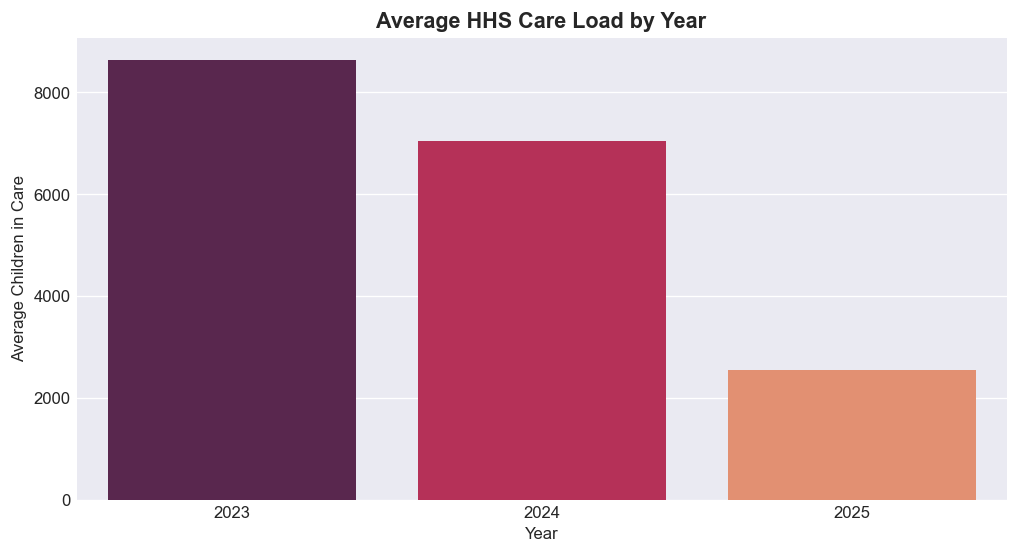

In [38]:
yearly = df.groupby('year')['hhs_care'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=yearly, x='year', y='hhs_care', palette='rocket')
plt.title('Average HHS Care Load by Year', fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Children in Care')

plt.savefig('../reports/figures/yearly_average.png', bbox_inches='tight')
plt.show()

### Net Flow Analysis

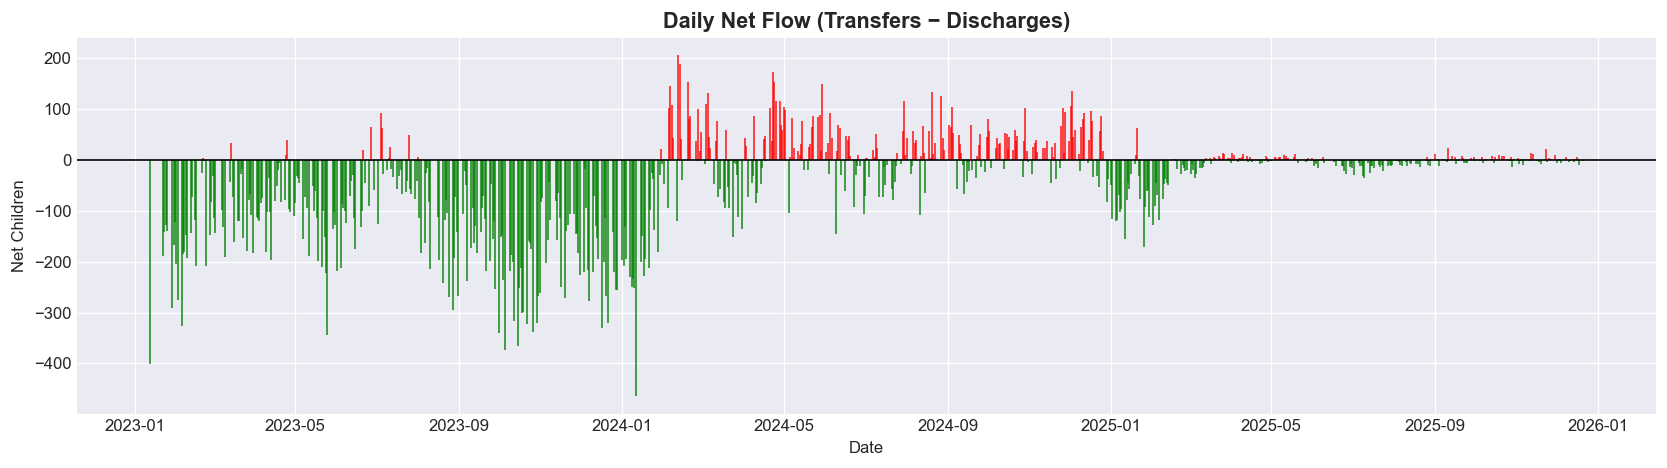

Average net flow: -44.74
Days with positive pressure (intake > discharge): 238
Days with relief (discharge > intake): 475


In [43]:
df['net_flow'] = df['cbp_transferred'] - df['hhs_discharged']

plt.figure(figsize=(14, 4))
plt.bar(df['Date'], df['net_flow'],
        color=df['net_flow'].apply(lambda x: 'red' if x > 0 else 'green'),
        width=1.5, alpha=0.7)
plt.axhline(y=0, color='black', linewidth=1)
plt.title('Daily Net Flow (Transfers − Discharges)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Net Children')
plt.tight_layout()
plt.savefig('../reports/figures/net_flow.png', bbox_inches='tight')
plt.show()

print(f"Average net flow: {df['net_flow'].mean():.2f}")
print(f"Days with positive pressure (intake > discharge): {(df['net_flow'] > 0).sum()}")
print(f"Days with relief (discharge > intake): {(df['net_flow'] < 0).sum()}")

df.drop(columns=['net_flow'], inplace=True)

### Distribution of Each Variable

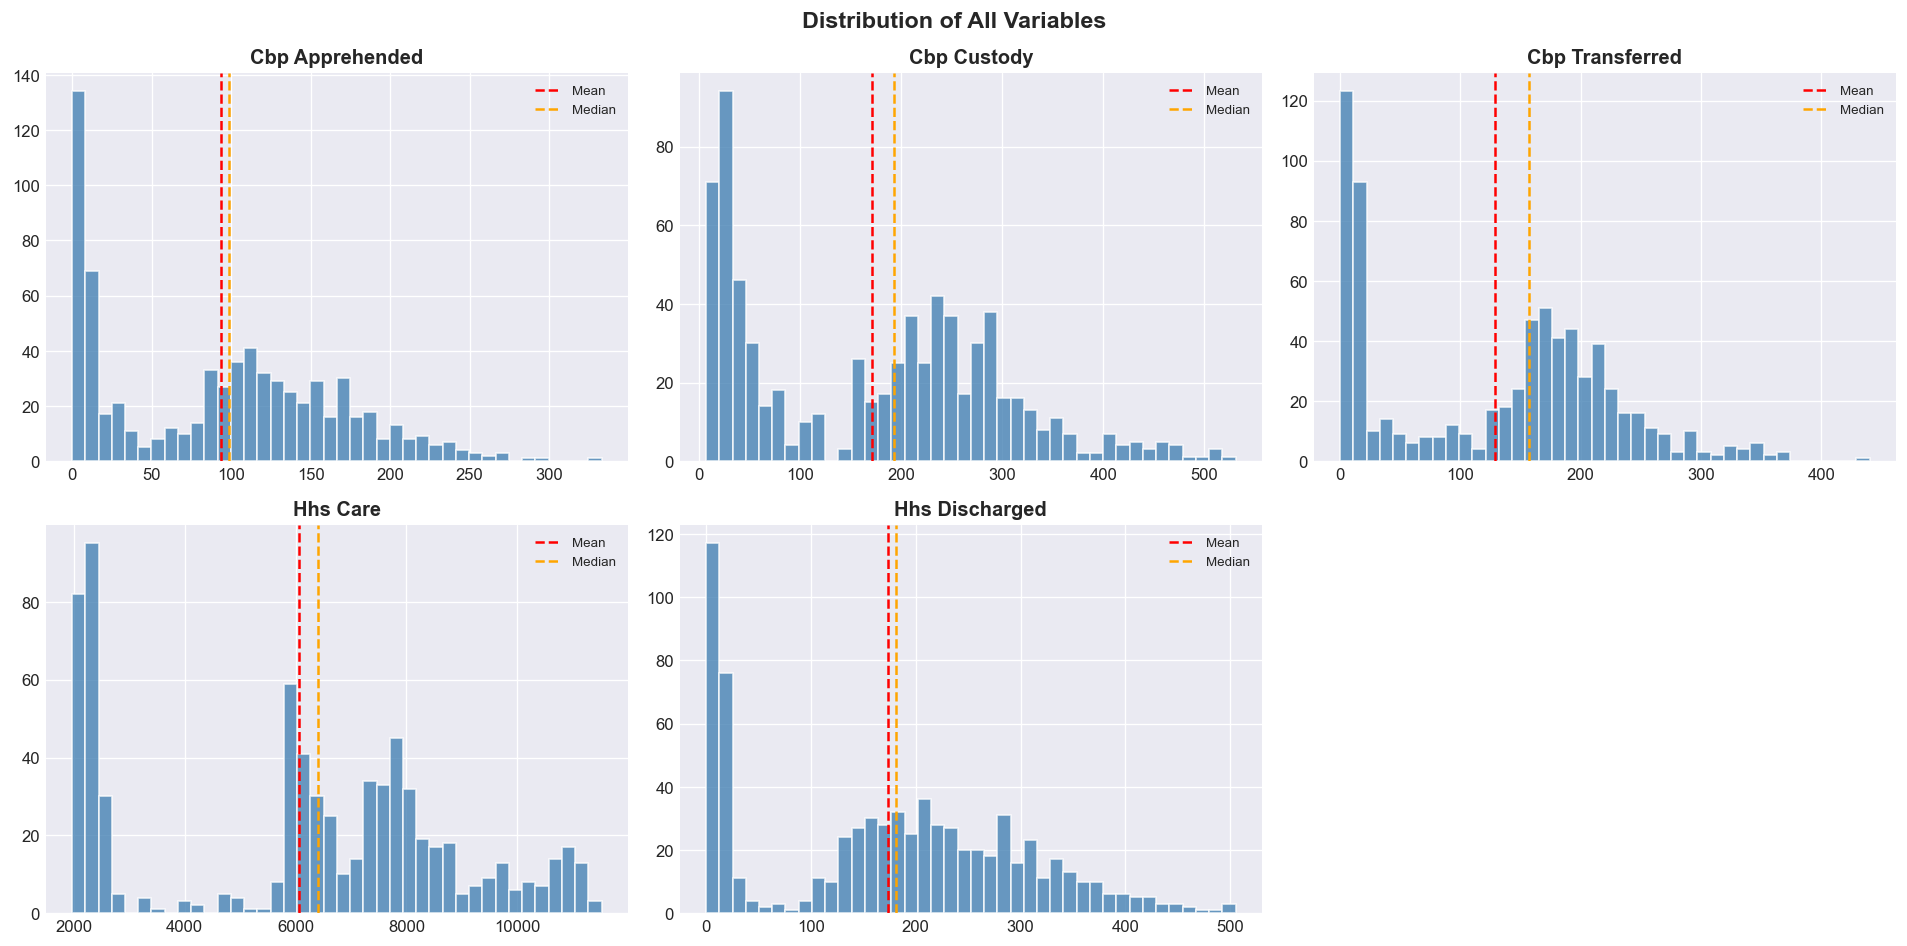

In [44]:
cols = ['cbp_apprehended', 'cbp_custody', 'cbp_transferred', 'hhs_care', 'hhs_discharged']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.5, label='Mean')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', linewidth=1.5, label='Median')
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].legend(fontsize=8)

axes[5].set_visible(False)
plt.suptitle('Distribution of All Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/distributions.png', bbox_inches='tight')
plt.show()

### EDA Summary

In [48]:

print("         EDA SUMMARY — KEY FINDINGS")

print(f"  Dataset period   : {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"  Total records    : {len(df)}")
print(f"  Missing dates    : 355 (weekends/holidays not recorded)")
print(f"  HHS Care range   : {df['hhs_care'].min()} to {df['hhs_care'].max()}")
print(f"  HHS Care mean    : {df['hhs_care'].mean():.0f}")
print(f"  Avg discharges   : {df['hhs_discharged'].mean():.0f} per day")
print(f"  Avg transfers in : {df['cbp_transferred'].mean():.0f} per day")
print(f"  Net flow (avg)   : {(df['cbp_transferred'] - df['hhs_discharged']).mean():.1f}")

print("  ACTION ITEMS FOR PREPROCESSING:")
print("  1. Handle 355 missing dates (interpolation)")
print("  2. Verify zero values in flow columns")
print("  3. Confirm no remaining nulls after cleaning")
print("  4. Reindex to full daily frequency")


         EDA SUMMARY — KEY FINDINGS
  Dataset period   : 2023-01-12 to 2025-12-21
  Total records    : 720
  Missing dates    : 355 (weekends/holidays not recorded)
  HHS Care range   : 1972 to 11516
  HHS Care mean    : 6061
  Avg discharges   : 173 per day
  Avg transfers in : 129 per day
  Net flow (avg)   : -44.7
  ACTION ITEMS FOR PREPROCESSING:
  1. Handle 355 missing dates (interpolation)
  2. Verify zero values in flow columns
  3. Confirm no remaining nulls after cleaning
  4. Reindex to full daily frequency
